In [1]:
# imports and plotting defaults
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from long_term_wear_plotting import (
    mask_to_segments,
    merge_close_segments,
    drop_tiny_segments,
    plot_group,
    plot_all_signals_one_figure,
    keep_min_duration_segments,
)

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = False

In [2]:
# fixed display settings
adc_ylim_map = {
    "ADC_ch0": (1.24, 1.34),  # Index
    "ADC_ch1": (1.30, 1.40),  # Thumb
    # "ADC_ch0": (1.2, 1.5),  # Index
    # "ADC_ch1": (1.2, 1.5),  # Thumb

}

label_colors = {
    "walking": "#5B8FF9", #blue
    "typing": "#61DDAA", #green
    "eating": "#F6BD16", #yellow-orange
    "texting": "#F08BB4", #pink
    "resting": "#9270CA", #purple
    "bluetooth down": "#7F7F7F", #gray
    "sensor disconnected": "#D62728", #red
    "IMU2 disconnected": "#D62728", #red
    "pressure": "#5B8FF9", #blue
    "bending": "#F6BD16", #yellow-orange

}

display_name_map = {
    "ADC_ch0": "Index MCP (raw ADC)",
    "ADC_ch1": "Thumb MP (raw ADC)",
    "IMU1_H": "Wrist IMU H",
    "IMU1_P": "Wrist IMU P",
    "IMU1_R": "Wrist IMU R",
    "IMU1_W": "Wrist IMU W",
    "IMU1_X": "Wrist IMU X",
    "IMU1_Y": "Wrist IMU Y",
    "IMU1_Z": "Wrist IMU Z",
    "IMU2_H": "HB IMU H",
    "IMU2_P": "HB IMU P",
    "IMU2_R": "HB IMU R",
    "IMU2_W": "HB IMU W",
    "IMU2_X": "HB IMU X",
    "IMU2_Y": "HB IMU Y",
    "IMU2_Z": "HB IMU Z",
}

group_title_map = {
    "IMU1 Euler": "Wrist IMU Euler",
    "IMU2 Euler": "HB IMU Euler",
    "IMU1 Quaternion": "Wrist IMU Quaternion",
    "IMU2 Quaternion": "HB IMU Quaternion",
    "ADC": "Strain Sensors",
}

In [3]:
# choose session
session_date = "2026_03_06"
file_pattern = "6hr2_kinwatch_unified_*.csv"
#file_pattern = "*_kinwatch_unified_*.csv" 

In [4]:
#loading file

# make Code/analysis importable so we can use the shared config.py
analysis_dir = Path.cwd().resolve().parent
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from config import path_to_repository

repo_dir = Path(path_to_repository).resolve()
data_root = repo_dir / "CSV Data" / "long_term_wear_data"

data_dir = data_root / session_date
csv_files = sorted(data_dir.glob(file_pattern))
if not csv_files:
    raise FileNotFoundError(f"No files matching {file_pattern} found in {data_dir}")

csv_path = csv_files[-1]
print("Using file:", csv_path)

df = pd.read_csv(csv_path)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

t0 = df["Timestamp"].iloc[0]
df["elapsed_sec"] = (df["Timestamp"] - t0).dt.total_seconds()
df["elapsed_min"] = df["elapsed_sec"] / 60
df["elapsed_hr"]  = df["elapsed_sec"] / 3600

print("Start:", df["Timestamp"].iloc[0])
print("End:  ", df["Timestamp"].iloc[-1])
print(f"Duration: {df['elapsed_hr'].iloc[-1]:.2f} hr")
print("Shape:", df.shape)

Using file: /Users/hannas/Desktop/SNEL/kinematics/Strain-Sensor-/CSV Data/long_term_wear_data/2026_03_06/6hr2_kinwatch_unified_20260306_110308.csv


/var/folders/6l/jmrrplj15wj_v49y196hw0cm0000gp/T/ipykernel_2395/2698718275.py:21: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Start: 2026-03-06 19:03:08.764000+00:00
End:   2026-03-07 01:03:16.909000+00:00
Duration: 6.00 hr
Shape: (3093557, 30)


In [5]:
# inspect cols
list(df.columns)

['Timestamp',
 'Counter',
 'IMU1_H',
 'IMU1_P',
 'IMU1_R',
 'IMU1_W',
 'IMU1_X',
 'IMU1_Y',
 'IMU1_Z',
 'IMU1_sys',
 'IMU1_gyro',
 'IMU1_accel',
 'IMU1_mag',
 'IMU2_H',
 'IMU2_P',
 'IMU2_R',
 'IMU2_W',
 'IMU2_X',
 'IMU2_Y',
 'IMU2_Z',
 'IMU2_sys',
 'IMU2_gyro',
 'IMU2_accel',
 'IMU2_mag',
 'ADC_ch0',
 'ADC_ch1',
 'Note',
 'elapsed_sec',
 'elapsed_min',
 'elapsed_hr']

In [6]:
# printing rows with notes
if "Note" not in df.columns:
    raise ValueError("No 'Note' column found in this file.")

note_mask = df["Note"].fillna("").astype(str).str.strip() != ""
note_rows = df.loc[note_mask, ["Timestamp", "elapsed_min", "elapsed_hr", "Counter", "Note"]].copy()

print(f"Found {len(note_rows)} rows with notes")
note_rows

Found 7 rows with notes


,Timestamp,elapsed_min,elapsed_hr,Counter,Note
4276,2026-03-06 19:03:38.277000+00:00,0.491883,0.008198,62710,eating
73493,2026-03-06 19:11:35.456000+00:00,8.444867,0.140748,67480,laptop work
485503,2026-03-06 19:59:08.504000+00:00,55.995667,0.933261,95951,walking
526721,2026-03-06 20:03:54.284000+00:00,60.758667,1.012644,98801,sitting
666264,2026-03-06 20:20:07.913000+00:00,76.985817,1.283097,108488,walking w box
712388,2026-03-06 20:25:27.312000+00:00,82.309133,1.371819,111673,walking
1030904,2026-03-06 21:02:55.569000+00:00,119.780083,1.996335,133783,sitting


In [7]:
for _, row in note_rows.iterrows():
    print(f"{row['elapsed_min']:8.3f} min | {row['Timestamp']} | {row['Note']}")

end_min = df["elapsed_min"].iloc[-1]
print("end of recording:", end_min)

   0.492 min | 2026-03-06 19:03:38.277000+00:00 | eating
   8.445 min | 2026-03-06 19:11:35.456000+00:00 | laptop work
  55.996 min | 2026-03-06 19:59:08.504000+00:00 | walking
  60.759 min | 2026-03-06 20:03:54.284000+00:00 | sitting
  76.986 min | 2026-03-06 20:20:07.913000+00:00 | walking w box
  82.309 min | 2026-03-06 20:25:27.312000+00:00 | walking
 119.780 min | 2026-03-06 21:02:55.569000+00:00 | sitting
end of recording: 360.13575000000003


In [8]:
# pick cols to plot
plot_groups = {
    "IMU1 Euler": ["IMU1_H", "IMU1_P", "IMU1_R"],
    "IMU1 Quaternion": ["IMU1_W", "IMU1_X", "IMU1_Y", "IMU1_Z"],
    "IMU2 Euler": ["IMU2_H", "IMU2_P", "IMU2_R"],
    "IMU2 Quaternion": ["IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"],
    "ADC": ["ADC_ch0", "ADC_ch1"],
}

plot_groups = {
    k: [c for c in v if c in df.columns]
    for k, v in plot_groups.items()
    if any(c in df.columns for c in v)
}

plot_groups

{'IMU1 Euler': ['IMU1_H', 'IMU1_P', 'IMU1_R'],
 'IMU1 Quaternion': ['IMU1_W', 'IMU1_X', 'IMU1_Y', 'IMU1_Z'],
 'IMU2 Euler': ['IMU2_H', 'IMU2_P', 'IMU2_R'],
 'IMU2 Quaternion': ['IMU2_W', 'IMU2_X', 'IMU2_Y', 'IMU2_Z'],
 'ADC': ['ADC_ch0', 'ADC_ch1']}

In [9]:
# defining activity segments to shade
manual_segments = [
    # 6hr
    # {"start_min": 1.645383	, "end_min": 2.731767, "label": "texting"},
    # {"start_min": 22.442983	, "end_min": 24.432400, "label": "walking"},
    # {"start_min": 24.432400	, "end_min": 37.556183, "label": "eating"},
    # {"start_min": 37.795633	, "end_min": 51.315817, "label": "walking"},
    # {"start_min": 59.827533	, "end_min": 119.827533, "label": "resting"}, # end not real
    # {"start_min": 250.294733, "end_min": 252.248967, "label": "texting"},
    # {"start_min": 266.162883, "end_min": 296.162883, "label": "walking"}, # end not real
    # {"start_min": 310	, "end_min": end_min, "label": "resting"},

    # 6hr2
    {"start_min": 0	, "end_min": 8.444867	, "label": "eating"},
    {"start_min": 8.444867		, "end_min": 55.995667, "label": "typing"},
    {"start_min": 55.995667	, "end_min": 60.758667, "label": "walking"},
    {"start_min": 60.758667	, "end_min": 76.985817, "label": "resting"},
    {"start_min": 76.985817	, "end_min": 119.780083, "label": "walking"}, 
    {"start_min": 119.780083, "end_min": end_min, "label": "typing"},
    
    # pressure 
    # {"start_min": 0.502400		, "end_min": 1.235583, "label": "pressure"},
    # {"start_min": 1.235583	, "end_min": end_min, "label": "bending"},

]


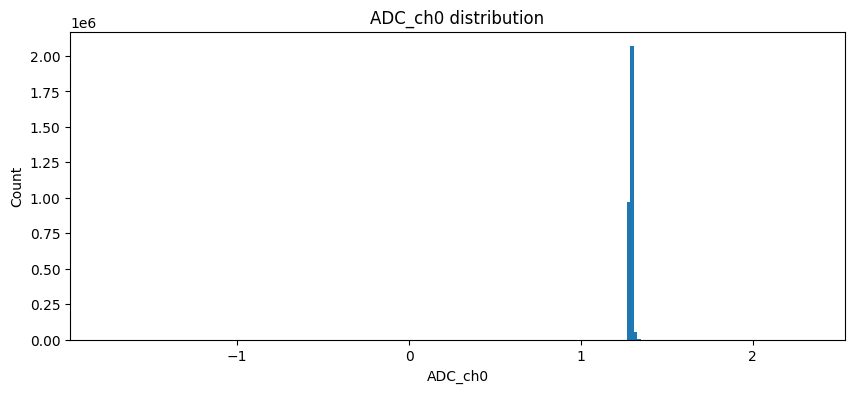

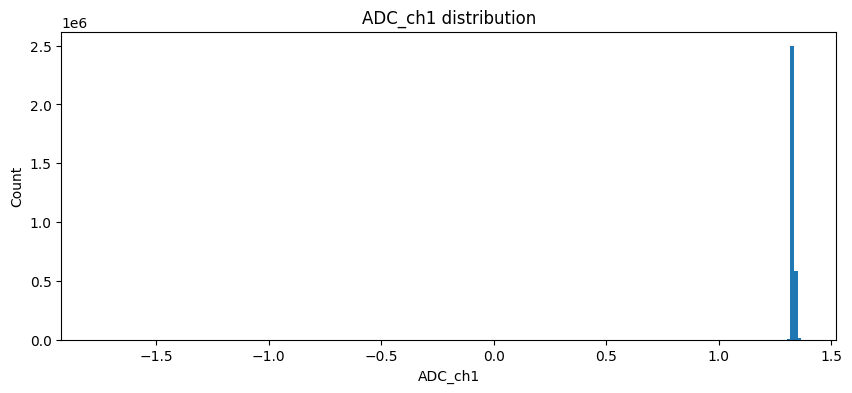

In [10]:
# inspecting ADC disttributions - help decide ylims & threshold
df[["ADC_ch0", "ADC_ch1"]].describe()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch0"].dropna(), bins=200)
plt.title("ADC_ch0 distribution")
plt.xlabel("ADC_ch0")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch1"].dropna(), bins=200)
plt.title("ADC_ch1 distribution")
plt.xlabel("ADC_ch1")
plt.ylabel("Count")
plt.show()

adc_disconnect_threshold = -1
gap_threshold_sec = 1

In [11]:
# detecting ADC disconnect
adc0_disconnected_mask = df["ADC_ch0"] < adc_disconnect_threshold
adc1_disconnected_mask = df["ADC_ch1"] < adc_disconnect_threshold

print("Rows flagged as ADC_ch0 disconnected:", int(adc0_disconnected_mask.sum()))
print("Rows flagged as ADC_ch1 disconnected:", int(adc1_disconnected_mask.sum()))

adc0_disconnect_segments = mask_to_segments(df, adc0_disconnected_mask, "sensor disconnected")
for seg in adc0_disconnect_segments:
    seg["channel"] = "ADC_ch0"

adc1_disconnect_segments = mask_to_segments(df, adc1_disconnected_mask, "sensor disconnected")
for seg in adc1_disconnect_segments:
    seg["channel"] = "ADC_ch1"

adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments
pd.DataFrame(adc_disconnect_segments).head(20)

Rows flagged as ADC_ch0 disconnected: 123
Rows flagged as ADC_ch1 disconnected: 51


,start_min,end_min,label,channel
0,73.782633,73.782933,sensor disconnected,ADC_ch0
1,73.784250,73.787667,sensor disconnected,ADC_ch0
2,73.789133,73.789133,sensor disconnected,ADC_ch0
3,73.931267,73.931467,sensor disconnected,ADC_ch0
4,73.932817,73.932817,sensor disconnected,ADC_ch0
5,73.934367,73.934367,sensor disconnected,ADC_ch0
6,73.946283,73.946417,sensor disconnected,ADC_ch0
7,73.947767,73.968283,sensor disconnected,ADC_ch0
8,73.969833,73.969833,sensor disconnected,ADC_ch0
9,291.342217,291.342517,sensor disconnected,ADC_ch1


In [12]:
# detecting IMU2 disconnect 
imu2_zero_like = df.loc[
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6),
    ["Timestamp", "elapsed_min", "IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
]

print(f"Rows with IMU2 quaternion all ~0: {len(imu2_zero_like)}")
imu2_zero_like.head(20)


imu2_disconnected_mask = (
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6) &
    (df["IMU2_P"].abs() < 1e-6) &
    (df["IMU2_R"].abs() < 1e-6) &
    ((df["IMU2_H"] - 360).abs() < 1e-6)
)

print("Rows flagged as IMU2 disconnected:", int(imu2_disconnected_mask.sum()))
imu2_disconnect_segments = mask_to_segments(df, imu2_disconnected_mask, "IMU2 disconnected")

imu2_disconnect_segments_df = pd.DataFrame(imu2_disconnect_segments)
imu2_disconnect_segments_df.head(20)

Rows with IMU2 quaternion all ~0: 67153
Rows flagged as IMU2 disconnected: 67124


,start_min,end_min,label
0,18.840700,18.896117,IMU2 disconnected
1,18.941233,18.996733,IMU2 disconnected
2,24.707283,24.762733,IMU2 disconnected
3,29.419417,29.474850,IMU2 disconnected
4,32.240783,32.299800,IMU2 disconnected
5,55.661417,55.716950,IMU2 disconnected
6,60.662817,60.718300,IMU2 disconnected
7,69.752950,69.808317,IMU2 disconnected
8,69.841783,69.897300,IMU2 disconnected
9,70.185950,70.241433,IMU2 disconnected


In [13]:
# detecting bluetooth-down
# dt_sec was around 0.002 -- so setting threshold to 0.5s for now
df["dt_sec"] = df["Timestamp"].diff().dt.total_seconds()
print(df["dt_sec"].describe())

gap_rows = df[df["dt_sec"] > gap_threshold_sec].copy()
print(f"Initially found {len(gap_rows)} possible Bluetooth gaps > {gap_threshold_sec} s")

bluetooth_segments = []

for idx in gap_rows.index:
    if idx == 0:
        continue

    prev_imu2_disc = bool(imu2_disconnected_mask.iloc[idx - 1]) if idx - 1 in imu2_disconnected_mask.index else False
    curr_imu2_disc = bool(imu2_disconnected_mask.iloc[idx]) if idx in imu2_disconnected_mask.index else False

    if prev_imu2_disc or curr_imu2_disc:
        continue

    bluetooth_segments.append({
        "start_min": float(df.loc[idx - 1, "elapsed_min"]),
        "end_min": float(df.loc[idx, "elapsed_min"]),
        "label": "bluetooth down",
        "gap_sec": float(df.loc[idx, "dt_sec"]),
        "start_time": df.loc[idx - 1, "Timestamp"],
        "end_time": df.loc[idx, "Timestamp"],
    })

bluetooth_segments_df = pd.DataFrame(bluetooth_segments)
print(f"Bluetooth gaps kept after excluding IMU2-disconnect boundaries: {len(bluetooth_segments)}")
bluetooth_segments_df

count    3.093556e+06
mean     6.984889e-03
std      1.988956e-02
min      0.000000e+00
25%      1.000000e-03
50%      2.000000e-03
75%      2.000000e-03
max      6.588000e+00
Name: dt_sec, dtype: float64
Initially found 14 possible Bluetooth gaps > 1 s
Bluetooth gaps kept after excluding IMU2-disconnect boundaries: 0


""


In [14]:
# clean up auto-detected segments
adc0_disconnect_segments = merge_close_segments(adc0_disconnect_segments, max_gap_min=0.005)
adc1_disconnect_segments = merge_close_segments(adc1_disconnect_segments, max_gap_min=0.005)
imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.005)
bluetooth_segments = merge_close_segments(bluetooth_segments, max_gap_min=0.01)

adc0_disconnect_segments = drop_tiny_segments(adc0_disconnect_segments, min_duration_min=0.002)
adc1_disconnect_segments = drop_tiny_segments(adc1_disconnect_segments, min_duration_min=0.002)
imu2_disconnect_segments = drop_tiny_segments(imu2_disconnect_segments, min_duration_min=0.002)
bluetooth_segments = drop_tiny_segments(bluetooth_segments, min_duration_min=0.002)

imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.05)
imu2_disconnect_segments = keep_min_duration_segments(imu2_disconnect_segments, min_duration_min=0.25)

adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments

print("ADC_ch0 cleaned segments:", len(adc0_disconnect_segments))
print("ADC_ch1 cleaned segments:", len(adc1_disconnect_segments))
print("IMU2 cleaned segments:", len(imu2_disconnect_segments))
print("Bluetooth cleaned segments:", len(bluetooth_segments))
print("Combined ADC cleaned segments:", len(adc_disconnect_segments))

ADC_ch0 cleaned segments: 3
ADC_ch1 cleaned segments: 1
IMU2 cleaned segments: 1
Bluetooth cleaned segments: 0
Combined ADC cleaned segments: 4


In [15]:
# replace with NaNs
df_plot = df.copy()

if "ADC_ch0" in df_plot.columns:
    df_plot.loc[adc0_disconnected_mask, "ADC_ch0"] = np.nan

if "ADC_ch1" in df_plot.columns:
    df_plot.loc[adc1_disconnected_mask, "ADC_ch1"] = np.nan

imu2_cols = ["IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
for col in imu2_cols:
    if col in df_plot.columns:
        df_plot.loc[imu2_disconnected_mask, col] = np.nan

In [16]:
# chronological segment table
all_segments_chron = []

for seg in manual_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "manual"
    })

for seg in bluetooth_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

for seg in adc_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": seg.get("channel", "auto")
    })

for seg in imu2_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

if all_segments_chron:
    all_segments_chron_df = (
        pd.DataFrame(all_segments_chron)
        .sort_values(["start_min", "end_min"])
        .reset_index(drop=True)
    )
else:
    all_segments_chron_df = pd.DataFrame(columns=["start_min", "end_min", "label", "source"])

all_segments_chron_df

,start_min,end_min,label,source
0,0.000000,8.444867,eating,manual
1,8.444867,55.995667,typing,manual
2,55.995667,60.758667,walking,manual
3,60.758667,76.985817,resting,manual
4,73.782633,73.789133,sensor disconnected,ADC_ch0
5,73.931267,73.934367,sensor disconnected,ADC_ch0
6,73.946283,73.969833,sensor disconnected,ADC_ch0
7,76.985817,119.780083,walking,manual
8,119.780083,360.135750,typing,manual
9,291.286533,291.708117,IMU2 disconnected,auto


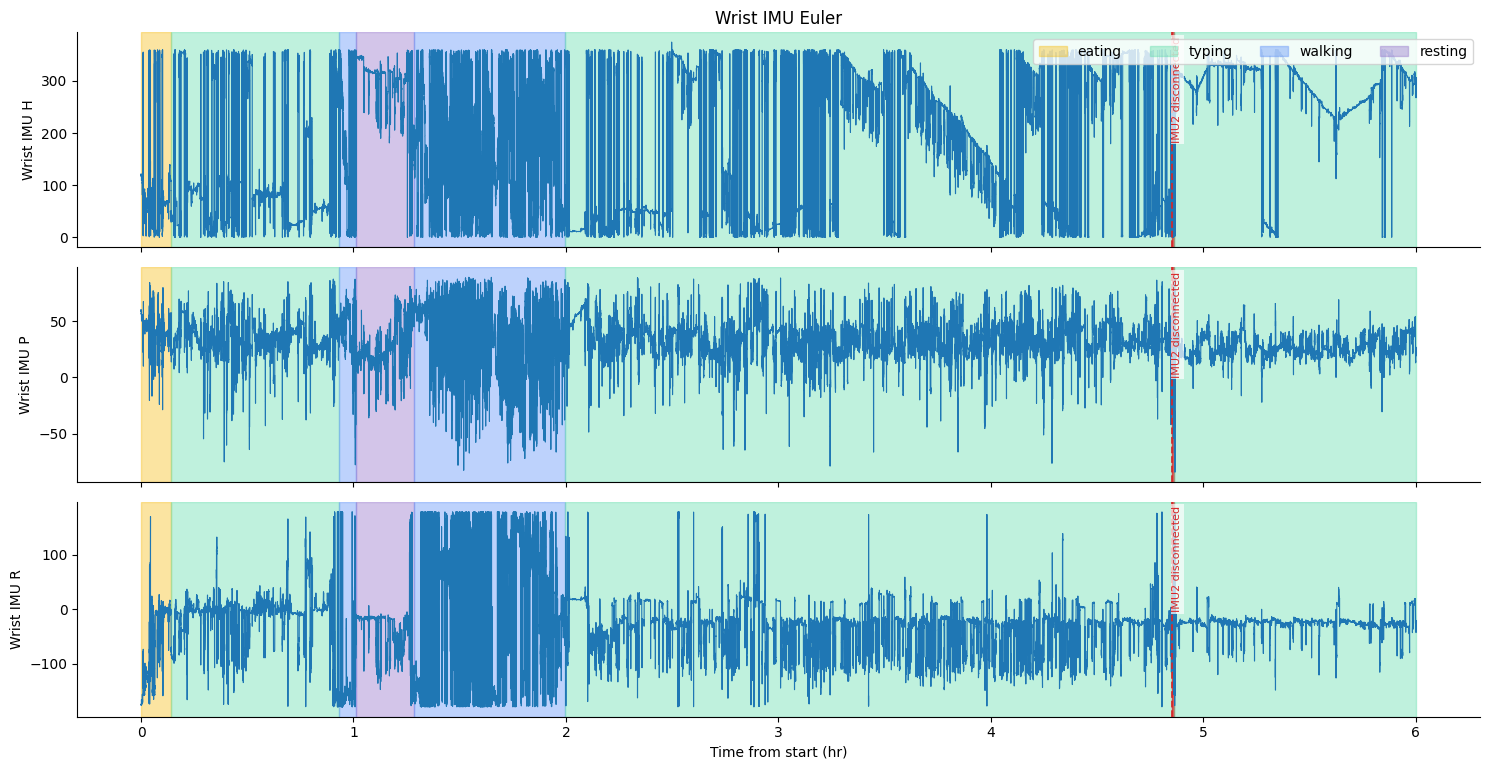

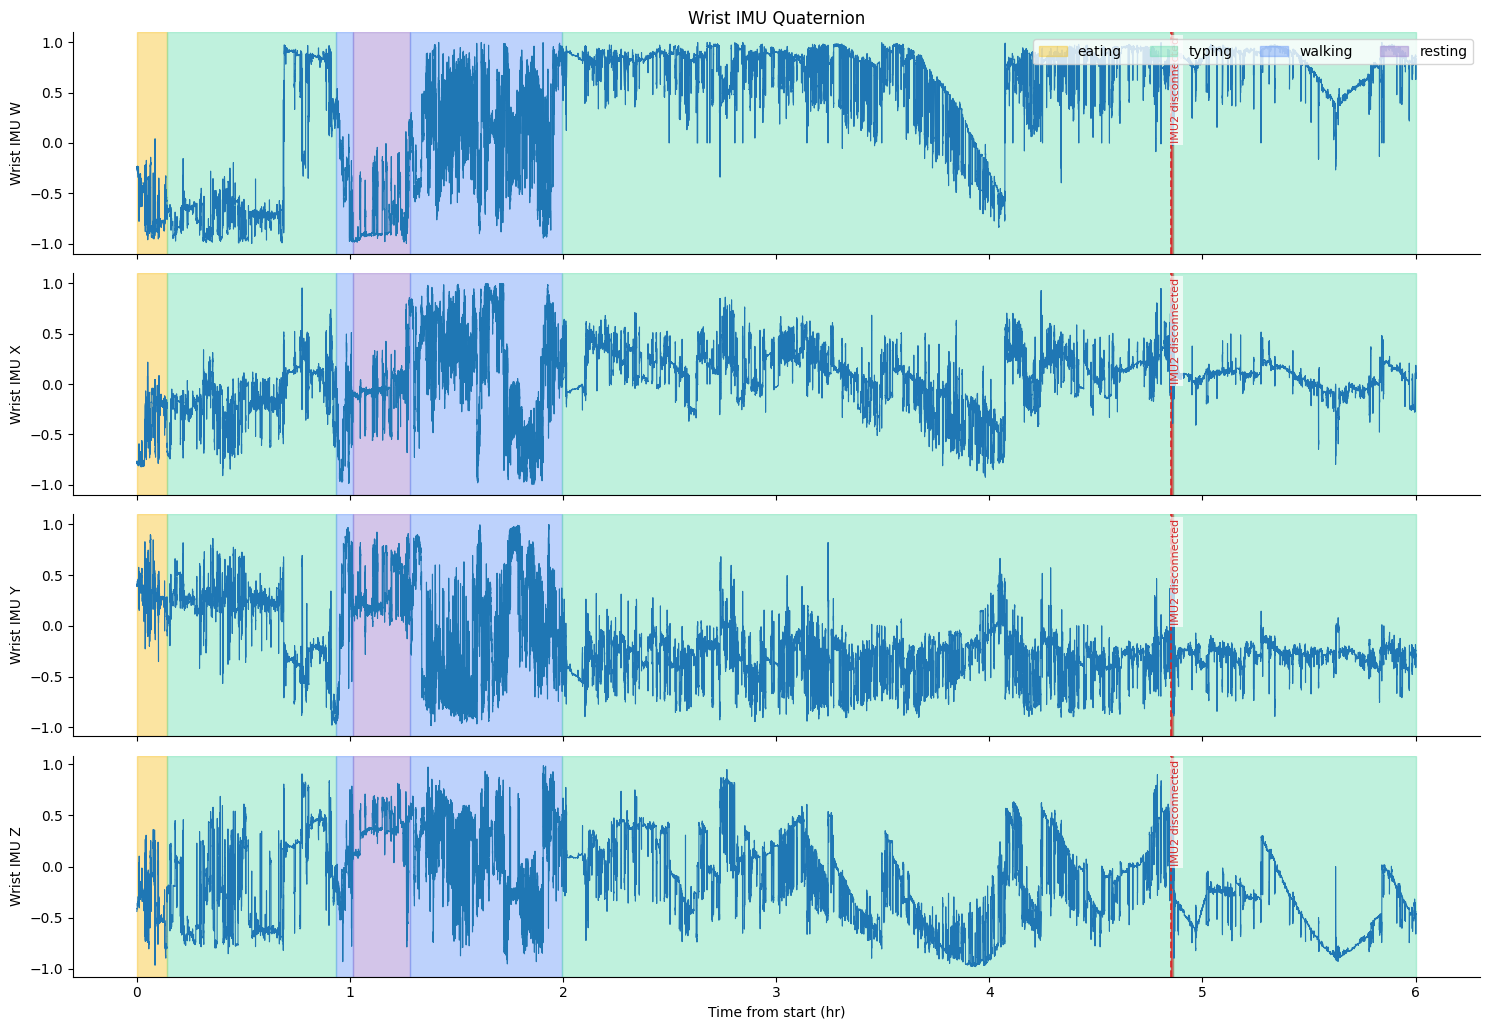

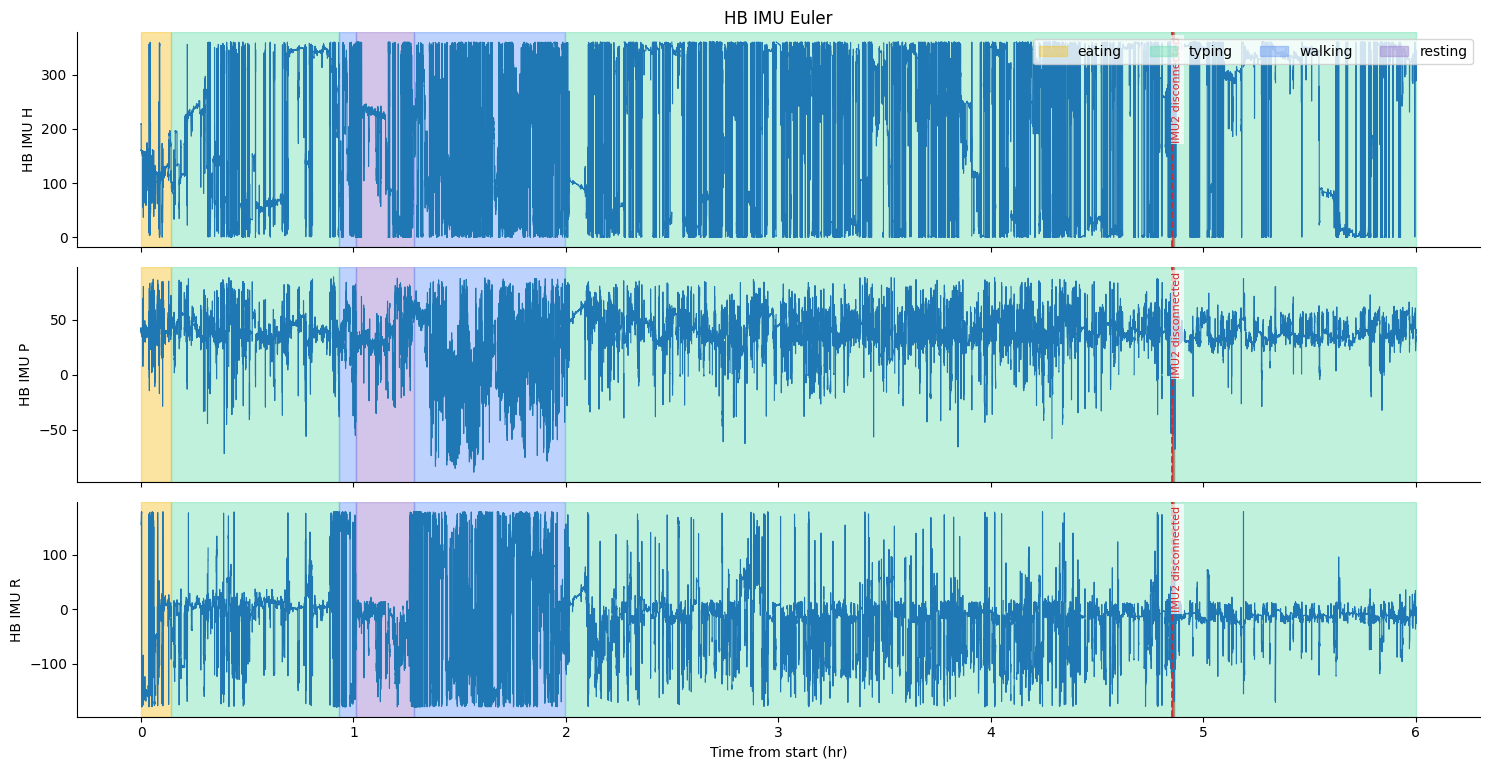

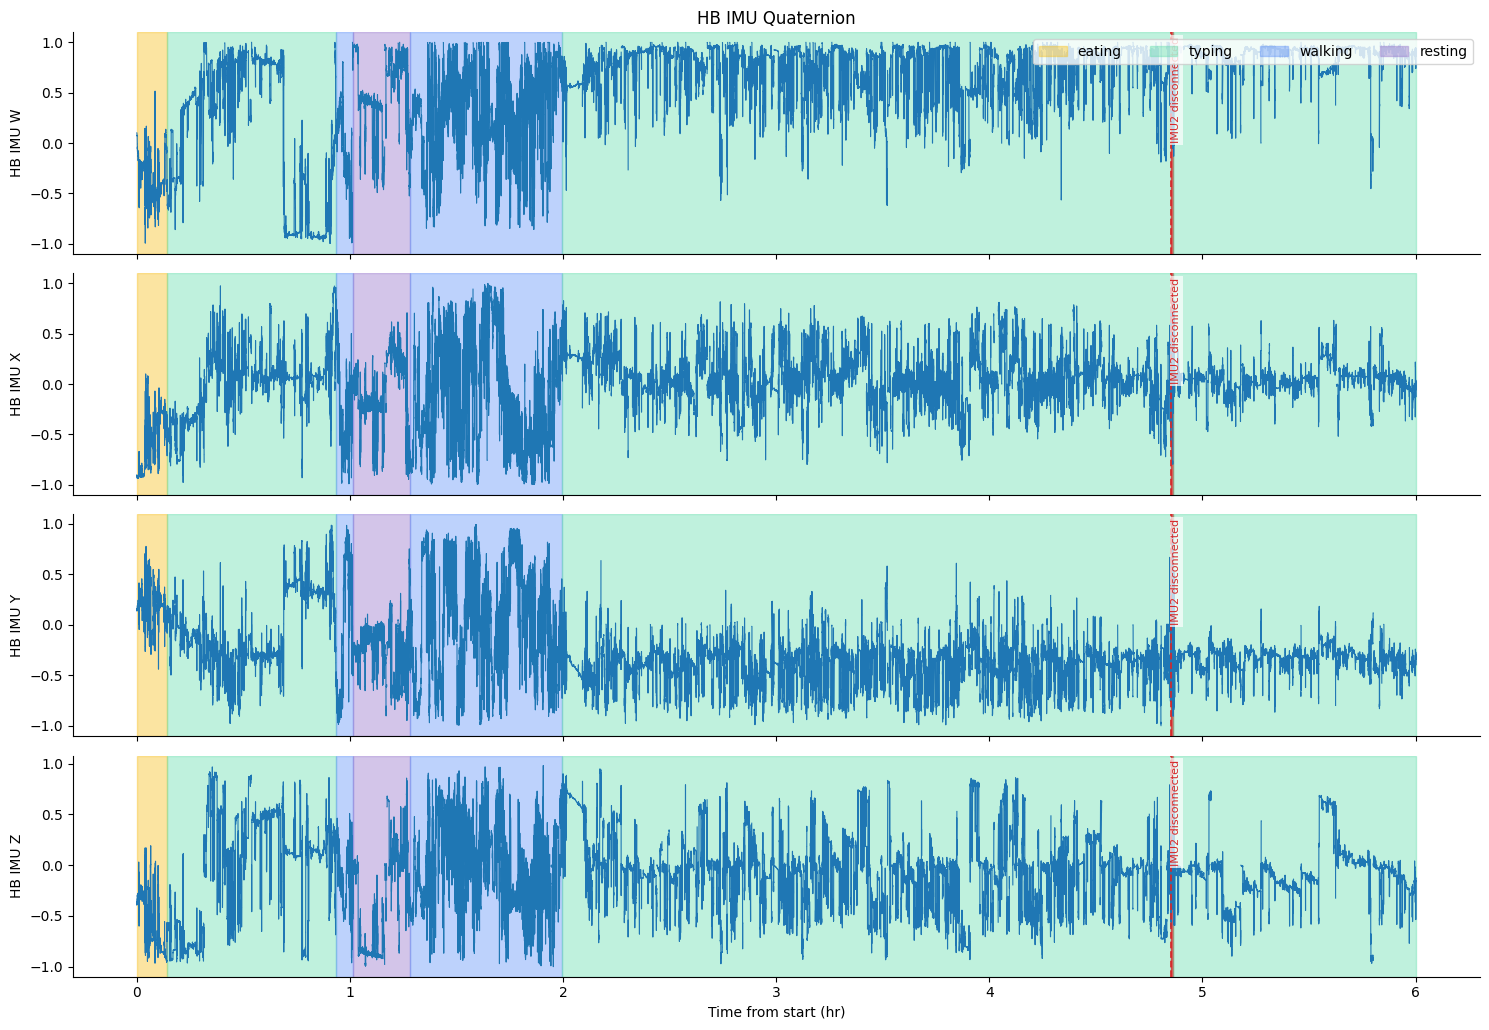

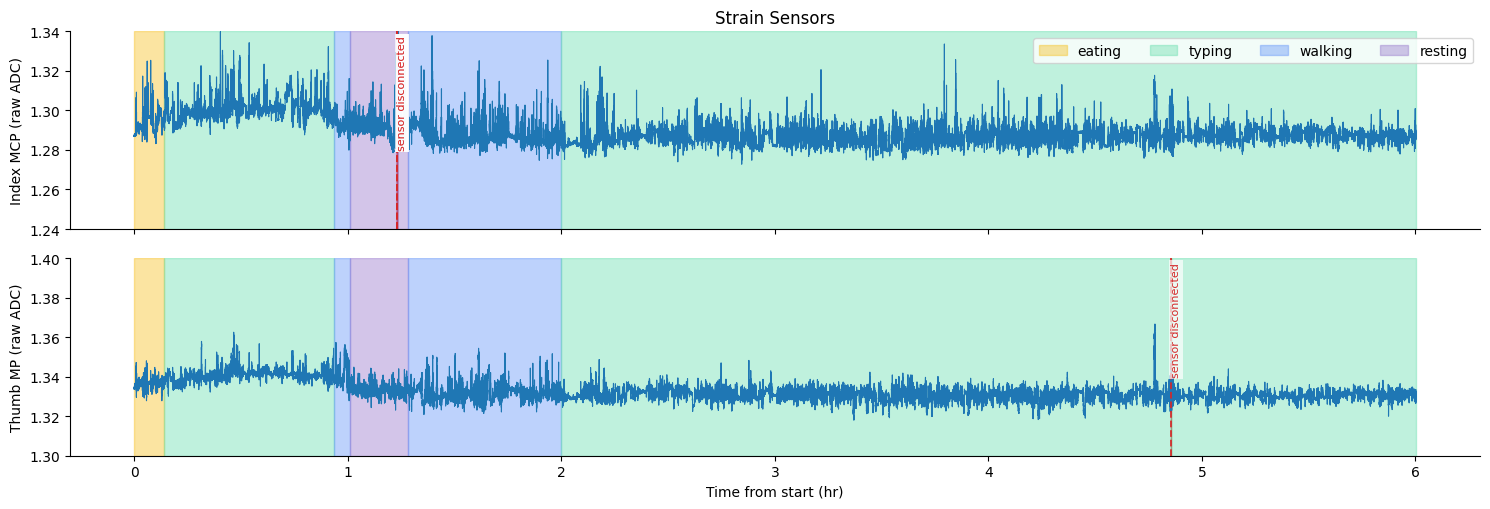

In [17]:
# individual plots
for title, cols in plot_groups.items():
    plot_group(
        df_plot,
        cols,
        title=title,
        manual_segments=manual_segments,
        bluetooth_segments=bluetooth_segments,
        adc_disconnect_segments=adc_disconnect_segments,
        imu2_disconnect_segments=imu2_disconnect_segments,
        label_colors=label_colors,
        display_name_map=display_name_map,
        group_title_map=group_title_map,
        adc_ylim_map=adc_ylim_map,
        xcol="elapsed_hr",
    )

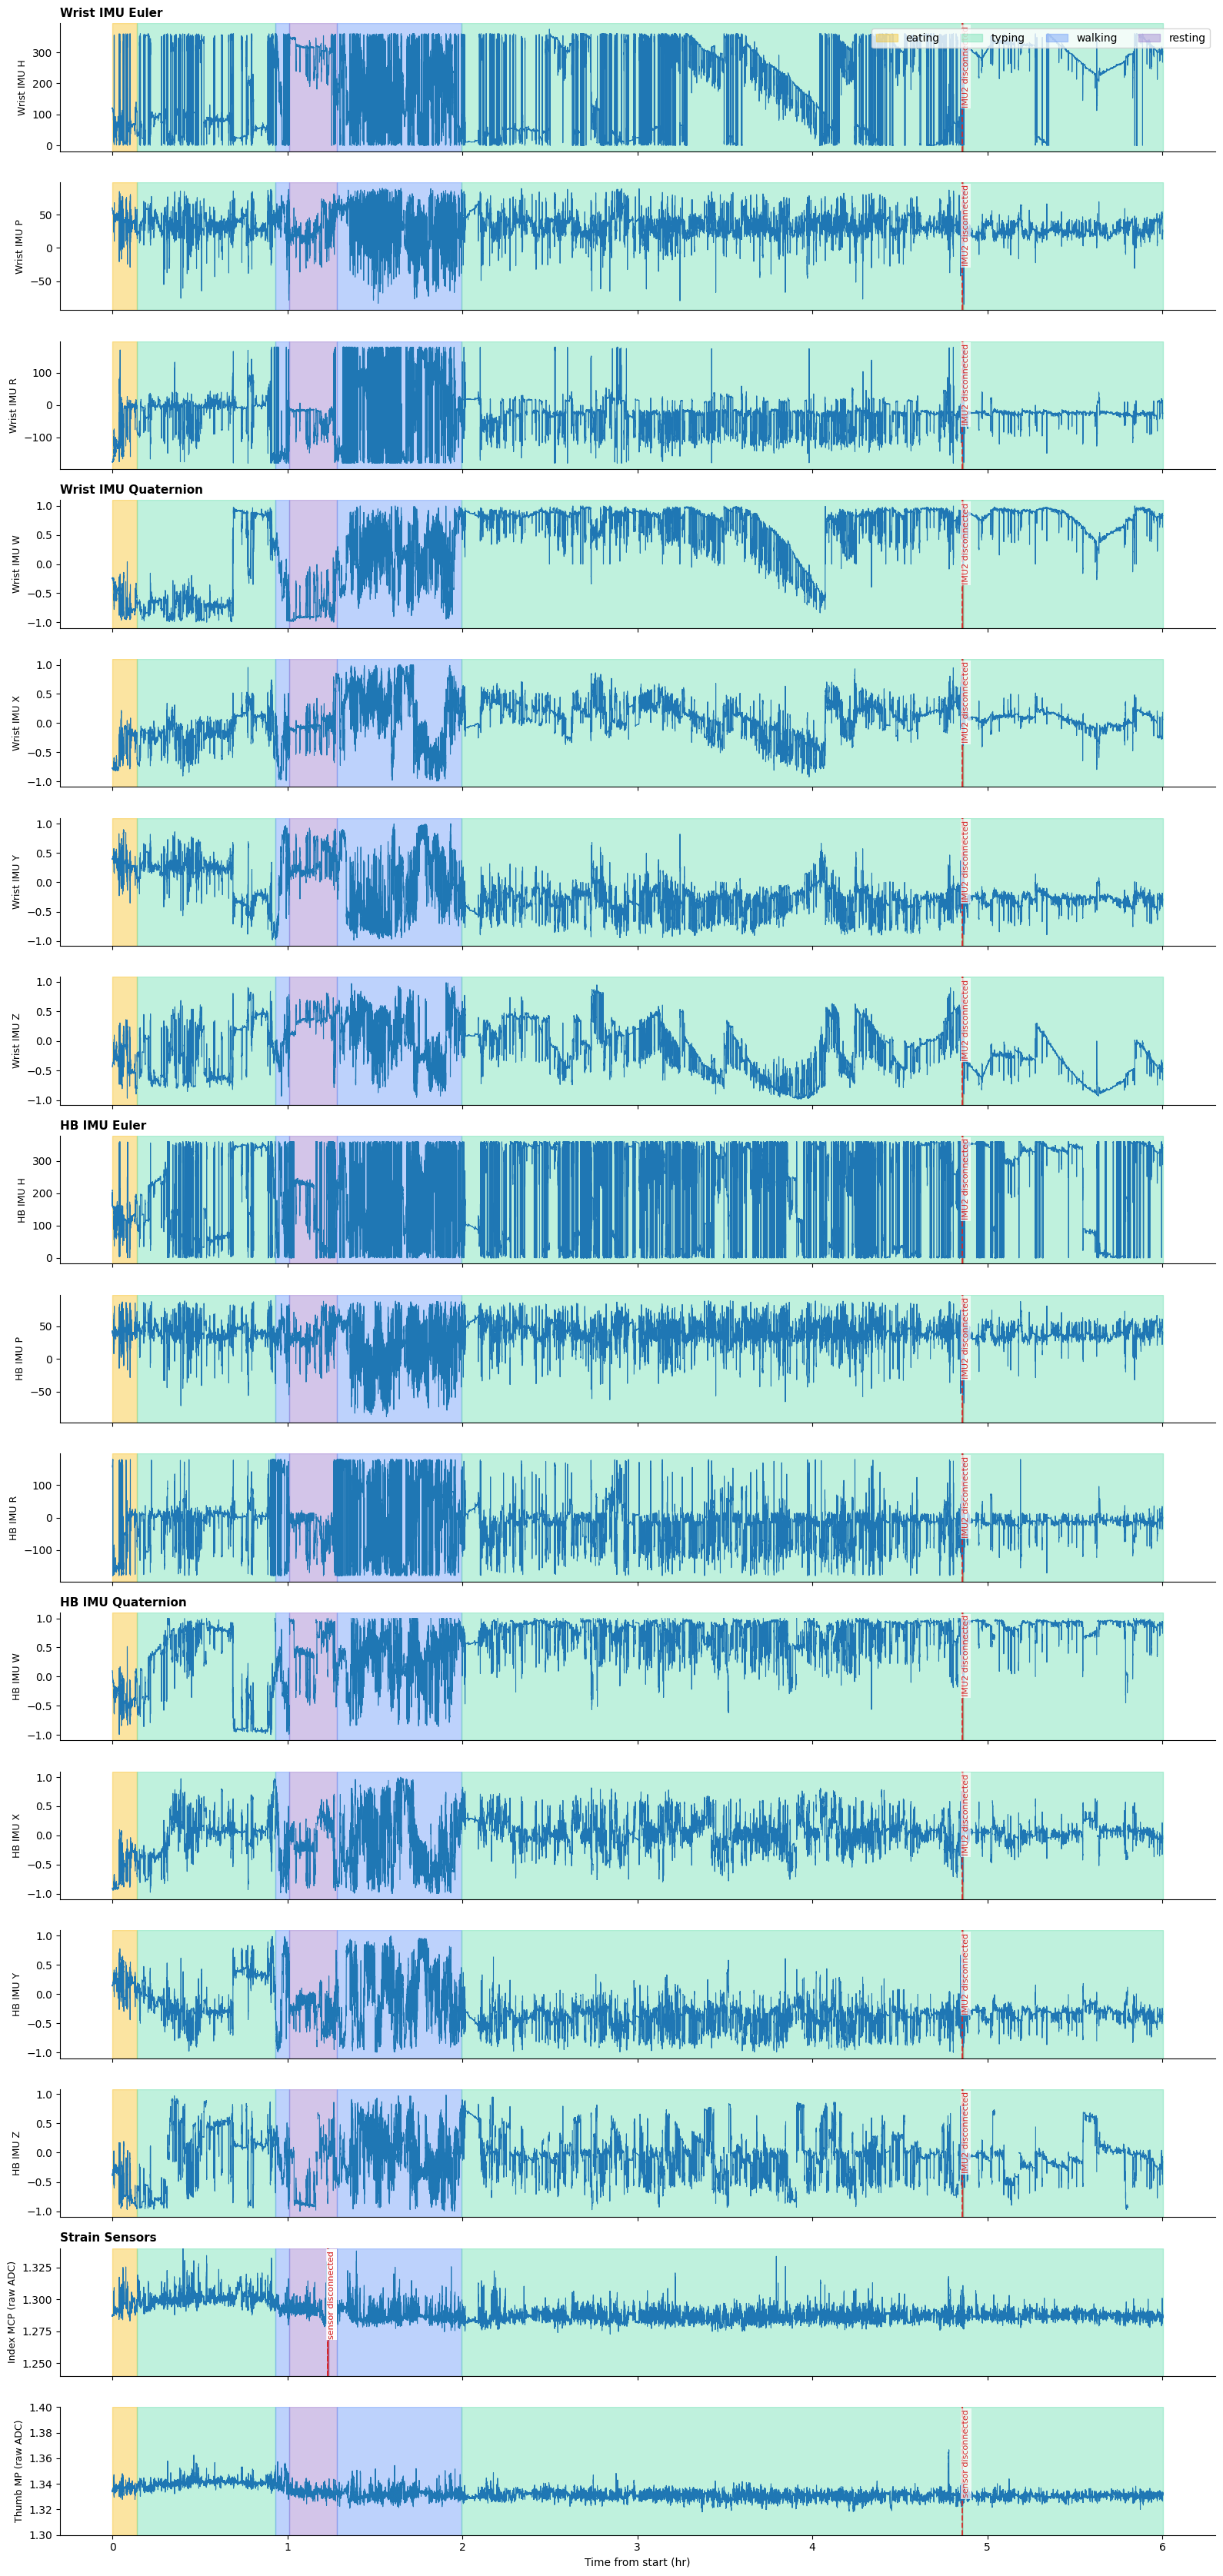

In [18]:
# combo plot
plot_all_signals_one_figure(
    df_plot,
    plot_groups,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map,
    xcol="elapsed_hr",
)